# Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
file_path = '../data/raw_sweeps' # add path to data 

from utils import update_rc_params

In [2]:
from sweep import sweep_load as sl
from sweep import raster
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline

from matplotlib.gridspec import GridSpec
from matplotlib.ticker import SymmetricalLogLocator
import matplotlib.patches as mpatches
from matplotlib.path import Path
from scipy.interpolate import splprep, splev
import h5py
from matplotlib.lines import Line2D
import pandas as pd

import sys
sys.path.append("../utils")
from utils import *

In [3]:
update_rc_params('talk')

# a - device schematic

In [4]:
from svglib.svglib import svg2rlg
from reportlab.graphics import renderPM
import matplotlib.pyplot as plt
from PIL import Image
import io

(np.float64(-0.5), np.float64(572.5), np.float64(369.5), np.float64(-0.5))

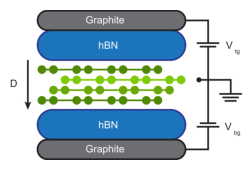

In [5]:
from svglib.svglib import svg2rlg
from reportlab.graphics import renderPM
import matplotlib.pyplot as plt
from PIL import Image
import io

drawing = svg2rlg("R4GDevice.svg")
png_bytes = renderPM.drawToString(drawing, fmt="PNG", dpi=400)

fig = plt.figure(figsize=(3, 4))
ax = plt.gca()
img = Image.open(io.BytesIO(png_bytes))
ax.imshow(img)
ax.axis("off")

# b - bandstructure

In [6]:
def plot_bandstructure(fig, ax):
    with h5py.File("../data/fig1/R4G_bandstructure_DOS_data.h5", "r") as f:
        uD_meV       = f["uD_meV"][:]
        ks_over_kc   = f["ks_over_kc"][:]
        # HDF5 stores Julia column-major arrays such that h5py reads them
        # back with reversed axes. The Julia exporter wrote
        #     Es_eV       (n_D, n_bands, Nk_line)
        #     dos_*       (n_D, Ndos_max)
        # so transpose on read to recover the documented shapes.
        Es_eV        = f["Es_eV"][:].T            # (n_D, n_bands, Nk)
        dos_rho      = f["dos_rho_per_Auc"][:].T  # (n_D, Ndos), NaN-padded
        dos_mu_eV    = f["dos_mu_eV"][:].T
        meVscale     = float(f["meVscale"][()])
        Mlayers      = int(f["Mlayers"][()])

        kc = 0.14154393696261794 #1/a_Gr
        a_Gr_nm = 0.246
        kxs_inv_nm = ks_over_kc * kc * (1/a_Gr_nm)
    
        n_D, n_bands, _ = Es_eV.shape
        pals = plt.get_cmap("magma_r")(np.linspace(0.2, 1, n_D))
    
        ymin, ymax = -50, 100   # meV — matches the Julia figure
        
        for d in range(n_D):
            for b in range(n_bands):
                ax.plot(kxs_inv_nm, meVscale * Es_eV[d, b, :],
                        color=pals[d], lw=1.0)
        ax.set_ylabel("Energy (meV)", labelpad=2)
        ax.set_xlabel(r"$k_x - K_x$ ($\mathrm{nm}^{-1}$)")
        ax.set_xticks(np.arange(-1.5, 1.51, 0.25), minor=True)
        ax.set_xlim(-0.7, 0.95)
    
        legend_handles = [
            Line2D([0], [0], color=pals[i], lw=1.5,
                   label=f"{int(round(uD_meV[d]))}")
            for i, d in enumerate(range(n_D))
        ]
    
        ax.set_ylim(ymin, ymax)
        ax.legend(
                handles=legend_handles,
                title=r"$u_D$ (meV)",
                loc=(0.75, 0.09),
                frameon=False,
        )
        ax.xaxis.set_major_locator(plt.MaxNLocator(3))
        ax.yaxis.set_major_locator(plt.MaxNLocator(3))
        return 
    
     

['/home/aaron/Fermiology-and-the-cCSC/figs/fig1_bandstructure.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig1_bandstructure.png']

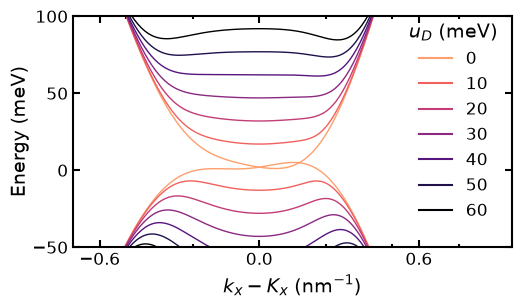

In [7]:
fig = plt.figure(figsize=(3.5*1.618, 3))
ax = plt.gca()
plot_bandstructure(fig, ax)
save_fig(fig, 'fig1_bandstructure')

## c - single particle theory dos

In [8]:
def plot_single_particle_dos_nD(fig, ax, norm, cmap, xlims, ylims, cb_width=0.5, inset_zoom=0.01): 
    with h5py.File('../data/fig1/R4G_DOS_data.h5', 'r') as f:
        Ds = f['Ds'][:]
        ns = f['ns'][:]
        rhos_per_Auc = f['rhos_per_Auc'][:]
    pernm2_convertor = 19.081
    plot = plt.pcolormesh(ns, Ds, rhos_per_Auc*pernm2_convertor, cmap=cmap, norm=norm, rasterized=True, lw=0)
    ax = plt.gca()
    ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
    ax.set_ylabel(r'$u_D$ (meV)')
    ax.set_xlim(xlims[0], xlims[1])
    ax.set_ylim(ylims[0], ylims[1])
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    
    #pos = ax.get_position()
    #cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])
    
    #cb = plt.colorbar(plot, cax=cax, ticks=[0, 10], \
    #                  orientation='horizontal')
    #cb.ax.annotate(r'DOS (eV$^{-1}\mathrm{nm}^{-2}$)', xy=(-0.10, 0.5), xycoords='axes fraction',
    #               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
    #cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
    #cb.ax.xaxis.set_label_position('top')  

    return plot

['/home/aaron/Fermiology-and-the-cCSC/figs/fig1_spdos.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig1_spdos.png']

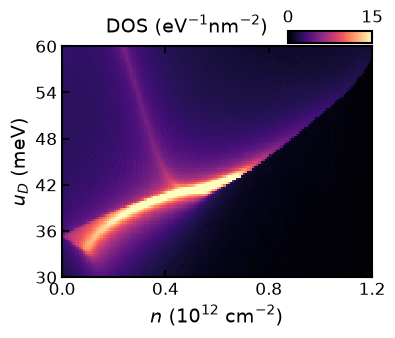

In [9]:
def plot_single_particle_dos_nD(fig, ax, norm, cmap, xlims, ylims, cb_width=0.5, inset_zoom=0.01):
    # Load from CSV: columns (n, uD, DOS)
    df = pd.read_csv('../data/fig1/DOS_n_uD_sandy.csv', header=None, names=['n', 'uD', 'DOS'])
    pivot = df.pivot(index='uD', columns='n', values='DOS')
    ns = pivot.columns.values
    Ds = pivot.index.values
    rhos = pivot.values  # shape (n_uD, n_n)

    # Unit conversion: CSV DOS is in eV^-1 nm^-2
    pernm2_convertor = 1
    plot = ax.pcolormesh(ns, Ds, rhos * pernm2_convertor,
                         cmap=cmap, norm=norm, shading="nearest",rasterized=True, lw=0)

    ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
    ax.set_ylabel(r'$u_D$ (meV)')
    ax.set_xlim(xlims[0], xlims[1])
    ax.set_ylim(ylims[0], ylims[1])
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))

    return plot


fig = plt.figure(figsize=(4,3))
ax = plt.gca()
norm = colors.Normalize(vmin=0.0, vmax=15)
plot = plot_single_particle_dos_nD(fig, ax, norm, cmap="magma", \
                                   xlims=[0,1.2], ylims=[30,60], cb_width=0.06, inset_zoom=0.025)

cax = fig.add_axes([0.69, 0.89, 0.21, 0.04])
cb = plt.colorbar(plot, cax=cax, ticks=SymmetricalLogLocator(base=10, linthresh=100), orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'DOS (eV$^{-1}\mathrm{nm}^{-2}$)', labelpad=-17, x=-1.2)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  

save_fig(fig, 'fig1_spdos')

## d - Wide gate map at zero field

In [10]:
def csc_patch(fig, ax, points):
    # Your boundary points (close the loop by repeating the first point)
    
    # Fit a smooth parametric spline
    tck, u = splprep([points[:, 0], points[:, 1]], s=0, per=True)
    u_fine = np.linspace(0, 1, 200)
    x_smooth, y_smooth = splev(u_fine, tck)
    
    # Build a matplotlib Path
    verts = np.column_stack([x_smooth, y_smooth])
    codes = [Path.MOVETO] + [Path.LINETO] * (len(verts) - 2) + [Path.CLOSEPOLY]
    
    path = Path(verts, codes)
    patch = mpatches.PathPatch(path, facecolor='none', edgecolor='white',
                               linewidth=1.5, alpha=1, zorder=5, ls="--")
    
    ax.add_patch(patch)

    return

/tmp/ipykernel_751995/3052523102.py:45: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


['/home/aaron/Fermiology-and-the-cCSC/figs/fig1_gatemap.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig1_gatemap.png']

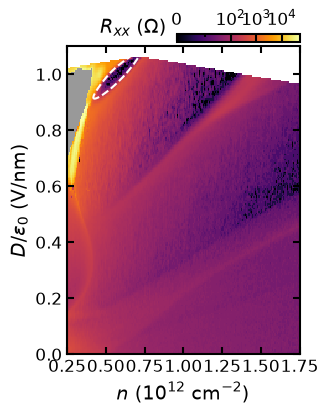

In [11]:
def plot_gatemap(ax, norm, cmap="viridis"):
    
    files= [1948] 
    ns = np.array([0.2, 0.72, 1.8, 1.8, 0.2])
    Ds = np.array([1.018, 1.065, 0.96, -0.4, -0.4])
    
    nx, ny = 201, 251
    
    verts = []
    for n, D in zip(ns, Ds):
        verts.append([n, D])
    verts = np.array(verts)
    
    Vtgs, Vbgs = calculate_gate_voltages(ns, Ds, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
    
    verts_gates = []
    for Vtg, Vbg in zip(Vtgs, Vbgs):
        verts_gates.append([Vtg, Vbg])
    verts_gates = np.array(verts_gates)
    
    contact_pairs = {
        'long bot': {'indices': [1], 'norm': norm, 'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            z_arr = []
            for file in files:
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                md = sl.load_meta(file_path, file)
                xs = data['xs'][0] # top gate
                ys = data['xs'][1] # back gate
        
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                Vxx = data[f'sr830_{ind}_X']
                Vxx = np.pad(Vxx, (0, len(xs.ravel()) - len(Vxx)), 'constant', constant_values=(np.nan, np.nan))
                zs = Vxx / I
                phase = data[f'sr830_{ind}_P']
                phase = np.pad(phase, (0, len(xs.ravel()) - len(phase)), 'constant', constant_values=(np.nan, np.nan))
                
                xs, ys = calculate_n_D(xs, ys, dtg=17.25, dbg=25.5)
                xs, ys, I = raster.pcolorize_data(I, verts, nx, ny, 1, rev_x=False, rev_y=False)
                xs, ys, zs = raster.pcolorize_data(zs, verts, nx, ny, 1, rev_x=False, rev_y=False)
                xs, ys, phase = raster.pcolorize_data(phase, verts, nx, ny, 1, rev_x=False, rev_y=False)
                mask = I/(md['comments'][1]['I_ac']*1E-9) < 0.1
                zs = np.ma.array(zs, mask=mask)
                z_arr.append(zs)

                finite = np.isfinite(I)
                mask = np.abs(I) < 0.7 * np.nanmax(I)
                zs_m = np.ma.array(zs, mask=mask | ~finite)
        
                plot = ax.pcolormesh(xs, ys, zs_m, norm=norm, cmap=cmap,rasterized=True, lw=0,zorder=1)
    
                zs_m = np.ma.array(np.ones(zs.shape), mask=~mask | ~finite)
                gray_cmap = colors.ListedColormap(["0.6"])
                ax.pcolormesh(xs, ys, zs_m, cmap=gray_cmap, shading="auto", rasterized=True, lw=0)

            ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
            ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
            ax.set_ylim(-0.28, 1.1)
            ax.set_xticks(0.25*np.arange(8))
            ax.set_xlim(0.25, 1.75)
            ax.set_ylim(0, 1.1)
        return plot


fig = plt.figure(figsize=(3,4))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=5E4)
plot = plot_gatemap(ax, norm, "inferno")

cax = fig.add_axes([0.49, 0.89, 0.41, 0.02])
cb = plt.colorbar(plot, cax=cax, ticks=SymmetricalLogLocator(base=10, linthresh=100), orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-17, x=-0.35)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  

points = np.array([[0.42, 0.92], [0.61, 0.99], [0.72, 1.08], [0.6, 1.04], \
                   [0.52, 1.0], [0.45, 0.93]])
csc_patch(fig, ax, points)
save_fig(fig, 'fig1_gatemap')

## Helper functions for annotation

In [12]:
def plot_metal_patches(ax, metal_type, position, size=1.0):
    """
    Plot spin-valley occupation schematic.
    
    Parameters
    ----------
    ax : matplotlib Axes
    metal_type : str
        'full', 'half', or 'quarter'
    position : tuple
        (x, y) center of the 2x2 grid
    size : float
        Side length of the full grid
    """
    configs = {
        'full':    [True, True, True, True],
        'half':    [True, True, False, False],
        'quarter': [True, False, False, False],
    }
    colors = ['#00FFAA', '#FFFF00', '#FF2060', '#00BBFF']
    blob_pts = np.array([[0.5, 0.70], [0.05, 0.15], [0.95, 0.15]])
    occupied = configs[metal_type]

    x0, y0 = position[0] - size/2, position[1] - size/2
    half = size / 2
    ysize = 0.8*size
    yhalf = ysize/2

    # Draw grid
    grid_rect = mpatches.Rectangle((x0, y0), size, ysize,
                                    facecolor='none', edgecolor='none',
                                    lw=0.5, zorder=4)
    ax.add_patch(grid_rect)
    ax.plot([x0 + half, x0 + half], [y0, y0 + ysize], 'w-', lw=0.5, zorder=10)
    ax.plot([x0, x0 + size], [y0 + yhalf, y0 + yhalf], 'w-', lw=0.5, zorder=10)

    # Quadrant offsets: top-left, top-right, bottom-left, bottom-right
    offsets = [(0, 1), (1, 1), (0, 0), (1, 0)]

    for occ, (qx, qy), color in zip(occupied, offsets, colors):
        if occ:
            pts = np.vstack([blob_pts, blob_pts[0]])
            tck, u = splprep([pts[:, 0], pts[:, 1]], s=0, per=True)
            u_fine = np.linspace(0, 1, 300)
            xb, yb = splev(u_fine, tck)
            # Scale and shift into quadrant
            xb = xb * 0.9 * half + x0 + qx * half + 0.05 * half
            yb = yb * 0.9 * half + y0 + qy * yhalf + 0.05 * yhalf
            verts = np.column_stack([xb, yb])
            codes = [1] + [2] * (len(verts) - 2) + [79]
            path = Path(verts, codes)
            patch = mpatches.PathPatch(path, facecolor='#22CC44', edgecolor='darkgreen',
                                       lw=0.5, zorder=5)
            ax.add_patch(patch)

## SCHF

In [13]:
def plot_schf(fig, ax, norm, cmap):
    pd={}
    pd['fname']='../data/fig1/collect_data.npz'
    pd['DOSfname']='../data/fig1/DOS_data.npz'
    pd['iUmax']=1000 #set to -4 to remove reduced-polarization phases at higher uD
    temp=np.load(pd['fname'],allow_pickle=True)
    temp=np.load(pd['fname'],allow_pickle=True)
  
    data=temp['collect_data'][:pd['iUmax']] #[iU,iepsr,ine,occ or unocc]
    
    Us=np.array(temp['Us']).astype(float)[:pd['iUmax']]
    epsrs=np.array(temp['epsrs']).astype(float)
    nelist=np.array(temp['nelist']).astype(float)
    numne=len(nelist)
    nU=len(Us)
    nepsr=len(epsrs)
    XX,YY=np.meshgrid(nelist,Us,indexing='ij')
    YY*=1e-9
    XX/=1e16
    
    DOS=np.load(pd['DOSfname'])['DOS_data']
    
    # print(data)
    for iepsr,epsr in enumerate(epsrs):
        if iepsr in [2]: 
            DOSproc=np.zeros((numne,nU))
            fracproc=np.zeros((numne,nU))
            for iU in range(nU):
                for ine in range(numne):
                    #only not-FP
                    if np.isnan(data[iU,iepsr,ine,0]) and not np.isnan(data[iU,iepsr,ine,1]):
                        fracproc[ine,iU]=data[iU,iepsr,ine,2]/np.sum(data[iU,iepsr,ine,2:6])
                        DOSproc[ine,iU]=DOS[iU,iepsr,ine,1]
                      #only FP
                    elif not np.isnan(data[iU,iepsr,ine,0]) and np.isnan(data[iU,iepsr,ine,1]):
                        fracproc[ine,iU]=1
                        DOSproc[ine,iU]=DOS[iU,iepsr,ine,0]
                    #FP lower energy
                    elif data[iU,iepsr,ine,1]>data[iU,iepsr,ine,0]:
                        fracproc[ine,iU]=1
                        DOSproc[ine,iU]=DOS[iU,iepsr,ine,0]  
                    #FP lower energy
                    elif data[iU,iepsr,ine,1]<data[iU,iepsr,ine,0]:
                        fracproc[ine,iU]=data[iU,iepsr,ine,2]/np.sum(data[iU,iepsr,ine,2:6])
                        DOSproc[ine,iU]=DOS[iU,iepsr,ine,1]
                    else:
                        print("ASEF")
    
    plot=ax.pcolormesh(XX,YY,DOSproc/1e18,cmap=cmap,shading='nearest', norm=norm, rasterized=True, lw=0)
    ax.set_xlabel(r"$n$ ($10^{12}$ cm$^{-2}$)")
    ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
    ax.set_xticks(0.25*np.arange(8))
    ax.set_xlim(0.25, 1.75)
    ax.set_ylim(0, 1.1)
    return plot

In [14]:
def plot_phase_boundary(fig, ax, points, edgecolor="white"):
    # Fit a smooth parametric spline
    tck, u = splprep([points[:, 0], points[:, 1]], s=0)
    u_fine = np.linspace(0, 1, 21)
    x_smooth, y_smooth = splev(u_fine, tck)
    ax.plot(x_smooth, y_smooth, color=edgecolor, linewidth=1.5, alpha=1, zorder=5, ls="--")
    
    return

['/home/aaron/Fermiology-and-the-cCSC/figs/fig1_schf.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig1_schf.png']

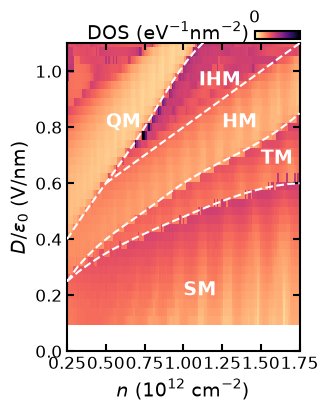

In [15]:
fig = plt.figure(figsize=(3,4))
ax = plt.gca()
norm = colors.Normalize(vmin=0, vmax=7)
plot = plot_schf(fig, ax, norm, "magma_r")

pos = ax.get_position()
cb_width = 0.15  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 10], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10$'])
cb.ax.annotate(r'DOS (eV$^{-1}\mathrm{nm}^{-2}$)', xy=(-0.10, 0.8), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  

pts = np.array([[0.25, 0.4],[0.5,0.60], [0.75, 0.8], [1.0,1.02],[1.25, 1.15]])
plot_phase_boundary(fig, ax, pts)
ax.text(0.5, 0.8, "QM", color="white", fontweight="bold")

pts = np.array([[0.5, 0.6],[0.75,0.7], [1.25, 0.9], [1.5,1], [1.75, 1.1]])
plot_phase_boundary(fig, ax, pts)
ax.text(1.1, 0.95, "IHM", color="white", fontweight="bold")

pts = np.array([[0.25, 0.25],[0.5,0.4], [0.75, 0.5], [1,0.6], [1.5, 0.75], [1.75, 0.85]])
plot_phase_boundary(fig, ax, pts)
ax.text(1.25, 0.8, "HM", color="white", fontweight="bold")

pts = np.array([[0.25, 0.25],[0.5,0.35], [0.75, 0.42], [1,0.48], [1.5, 0.58], [1.75, 0.60]])
plot_phase_boundary(fig, ax, pts)
ax.text(1.5, 0.67, "TM", color="white", fontweight="bold")

ax.text(1., 0.2, "SM", color="white", fontweight="bold")

#pts = np.array([[0.25, 15],[0.5,25], [0.75, 35], [1.1,53], [1.5, 70]])
#plot_phase_boundary(fig, ax, pts)
#ax.text(0.5, 40, "QM", color="white")

#pts = np.array([[0.25, 15],[0.5,25], [0.75, 33], [1,41], [1.75, 53]])
#plot_phase_boundary(fig, ax, pts)
#ax.text(1.1, 48, "iHM", color="white")

#pts = np.array([[0.25, 9],[0.5,15], [0.75, 21], [1,26], [1.5, 36], [1.75, 40]])
#plot_phase_boundary(fig, ax, pts)
#ax.text(1.25, 40, "HM", color="white")

#pts = np.array([[0.25, 9],[0.5,12], [0.75, 15], [1,20], [1.5, 27], [1.75, 31]])
#plot_phase_boundary(fig, ax, pts)
#ax.text(1.5, 32, "TM", color="white")

#ax.text(1., 10, "FM", color="white")
save_fig(fig, 'fig1_schf')

# Full figure

/tmp/ipykernel_751995/3052523102.py:45: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


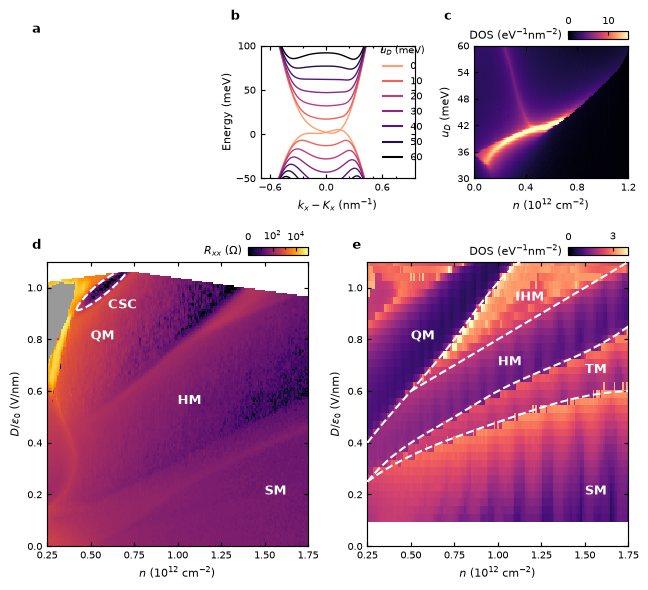

In [16]:
update_rc_params('paper')  # paper style for this final figure

# ── Global colorbar geometry ──────────────────────────────────────────────────
cb_width = 0.08          # colorbar width in figure fraction
cb_height_inches = 0.08  # colorbar height in physical inches (fixed across fig sizes)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(7.5, 6.5))
gs = GridSpec(2, 6, figure=fig,   
                       width_ratios=[1,1,1,1,1,1],
                       height_ratios=[0.35, 0.75],
                       hspace=0.4, wspace=1.25)

cb_height_frac = cb_height_inches / fig.get_size_inches()[1]

################ Panel a ##################
ax = fig.add_subplot(gs[0, 0:2])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "a", fontweight='bold')

ax.axis("off")
# add panels manually in inkscape

################ Panel b ##################
ax = fig.add_subplot(gs[0, 2:4])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "b", fontweight='bold')

plot_bandstructure(fig, ax)

################ Panel c ##################
ax = fig.add_subplot(gs[0, 4:6])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "c", fontweight='bold')

norm = colors.Normalize(vmin=0.0, vmax=15)
plot = plot_single_particle_dos_nD(fig, ax, norm, cmap="magma", \
                                   xlims=[0,1.2], ylims=[30,60], cb_width=0.06, inset_zoom=0.025)

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 10], \
                  orientation='horizontal')
cb.ax.annotate(r'DOS (eV$^{-1}\mathrm{nm}^{-2}$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  

################ Panel d ##################
ax = fig.add_subplot(gs[1, 0:3])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "d", fontweight='bold')

norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E5)
plot = plot_gatemap(ax, norm, "inferno")

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.annotate(r'$R_{xx}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')  

# patches
points = np.array([[0.42, 0.92], [0.61, 0.99], [0.72, 1.08], [0.6, 1.04], \
                   [0.52, 1.0], [0.45, 0.93]])
csc_patch(fig, ax, points)
ax.text(0.60, 0.92, "CSC", color="white", fontweight='bold')
ax.text(0.5, 0.8, "QM", color="white", fontweight="bold")
ax.text(1, 0.55, "HM", color="white", fontweight="bold")
ax.text(1.5, 0.2, "SM", color="white", fontweight="bold")

################ Panel e ##################
ax = fig.add_subplot(gs[1, 3:6])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "e", fontweight='bold')

norm = colors.Normalize(vmin=0, vmax=4)
plot = plot_schf(fig, ax, norm, "magma")

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 3], orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$3$'])
cb.ax.annotate(r'DOS (eV$^{-1}\mathrm{nm}^{-2}$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')  

pts = np.array([[0.25, 0.4],[0.5,0.60], [0.75, 0.8], [1.0,1.02],[1.25, 1.15]])
plot_phase_boundary(fig, ax, pts)
ax.text(0.5, 0.8, "QM", color="white", fontweight="bold")

pts = np.array([[0.5, 0.6],[0.75,0.7], [1.25, 0.9], [1.5,1], [1.75, 1.1]])
plot_phase_boundary(fig, ax, pts)
ax.text(1.1, 0.95, "IHM", color="white", fontweight="bold")

pts = np.array([[0.25, 0.25],[0.5,0.4], [0.75, 0.5], [1,0.6], [1.5, 0.75], [1.75, 0.85]])
plot_phase_boundary(fig, ax, pts)
ax.text(1, 0.7, "HM", color="white", fontweight="bold")

pts = np.array([[0.25, 0.25],[0.5,0.35], [0.75, 0.42], [1,0.48], [1.5, 0.58], [1.75, 0.60]])
plot_phase_boundary(fig, ax, pts)
ax.text(1.5, 0.67, "TM", color="white", fontweight="bold")

ax.text(1.5, 0.2, "SM", color="white", fontweight="bold")

plt.show()
#fig.savefig("fig1.pdf", dpi=300, bbox_inches='tight',
#            pad_inches=0.02, transparent=False)

plt.rcParams['svg.fonttype'] = 'none'
fig.savefig("fig1.svg", bbox_inches='tight',
            pad_inches=0.02, transparent=True)

update_rc_params('talk')  # restore presentation default